Step 1:   Import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

Step 2:       Load dataset

In [17]:
data = pd.read_csv("fertilizer.csv")

In [18]:
data

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,32,51,41,Red,Ground Nuts,7,3,19,14-35-14
1,35,58,35,Black,Cotton,4,14,16,Urea
2,27,55,43,Sandy,Sugarcane,28,0,17,20-20
3,33,56,56,Loamy,Ground Nuts,37,5,24,28-28
4,32,70,60,Red,Ground Nuts,4,6,9,14-35-14
...,...,...,...,...,...,...,...,...,...
99995,32,71,61,Black,Tobacco,23,1,25,20-20
99996,35,72,47,Loamy,Millets,38,1,32,17-17-17
99997,28,50,61,Sandy,Maize,10,11,14,14-35-14
99998,29,57,63,Loamy,Ground Nuts,7,10,4,DAP


Step 3:    EDA(Exploratory Data Analysis)

In [19]:
data.head()      ## understand dataset structure

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,32,51,41,Red,Ground Nuts,7,3,19,14-35-14
1,35,58,35,Black,Cotton,4,14,16,Urea
2,27,55,43,Sandy,Sugarcane,28,0,17,20-20
3,33,56,56,Loamy,Ground Nuts,37,5,24,28-28
4,32,70,60,Red,Ground Nuts,4,6,9,14-35-14


In [20]:
data.shape     ## check shape

(100000, 9)

In [21]:
data.columns    ## view column name

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')

In [22]:
data.info()    ## dataset information
                ## column types, null values, total entries

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Temparature      100000 non-null  int64 
 1   Humidity         100000 non-null  int64 
 2   Moisture         100000 non-null  int64 
 3   Soil Type        100000 non-null  object
 4   Crop Type        100000 non-null  object
 5   Nitrogen         100000 non-null  int64 
 6   Potassium        100000 non-null  int64 
 7   Phosphorous      100000 non-null  int64 
 8   Fertilizer Name  100000 non-null  object
dtypes: int64(6), object(3)
memory usage: 6.9+ MB


In [23]:
data.isnull().sum()   ## check missing values
                     ## datect empty cells

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [24]:
data.describe()    ## Statical summary
                   ## mean, min, max, standard deviation
                   ## Useful for understanding numeric data

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000
mean,31.503300,60.985810,45.00344,22.986770,9.472220,21.01348
std,4.019942,6.651393,11.83871,11.247289,5.768565,12.39118
min,25.000000,50.000000,25.00000,4.000000,0.000000,0.00000
25%,28.000000,55.000000,35.00000,13.000000,4.000000,10.00000
50%,32.000000,61.000000,45.00000,23.000000,9.000000,21.00000
75%,35.000000,67.000000,55.00000,33.000000,14.000000,32.00000
max,38.000000,72.000000,65.00000,42.000000,19.000000,42.00000


Step 4: Check Unique Value

In [25]:
data['Fertilizer Name'].unique

<bound method Series.unique of 0        14-35-14
1            Urea
2           20-20
3           28-28
4        14-35-14
           ...   
99995       20-20
99996    17-17-17
99997    14-35-14
99998         DAP
99999    17-17-17
Name: Fertilizer Name, Length: 100000, dtype: object>

Step 5: Encode Categorical Columns.

use LabelEncoder for:
. Soil Type
.Crop Type
.Fertilizer Name

In [26]:
le_soil = LabelEncoder()
data['Soil Type'] = le_soil.fit_transform(data['Soil Type'])

In [27]:
le_crop = LabelEncoder()
data['Crop Type'] = le_crop.fit_transform(data['Crop Type'])

In [28]:
le_fertilizer = LabelEncoder()


In [29]:
data['Fertilizer Name'] = le_fertilizer.fit_transform(data['Fertilizer Name'])

In [30]:
fertilizer_name = le_fertilizer.inverse_transform(prediction)

NameError: name 'prediction' is not defined

In [ ]:
le_soil

LabelEncoder()

In [ ]:
le_crop

LabelEncoder()

Step 6: Separate X an y

In [ ]:
x = data.drop('Fertilizer Name', axis = 1)

y = data['Fertilizer Name']

In [ ]:
x

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous
0,32,51,41,3,2,7,3,19
1,35,58,35,0,1,4,14,16
2,27,55,43,4,8,28,0,17
3,33,56,56,2,2,37,5,24
4,32,70,60,3,2,4,6,9
...,...,...,...,...,...,...,...,...
99995,32,71,61,0,9,23,1,25
99996,35,72,47,2,4,38,1,32
99997,28,50,61,4,3,10,11,14
99998,29,57,63,2,2,7,10,4


Step 7:   Train Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


Step 8: Train Model

In [ ]:
model = RandomForestClassifier()

model.fit(x_train, y_train)

RandomForestClassifier()

Step 9:  Prediction

In [ ]:
y_pred = model.predict(x_test)

Step 10:   Accuracy

In [ ]:
accuracy_score(y_test, y_pred)

0.1453

Step 11: Confusion Matrix

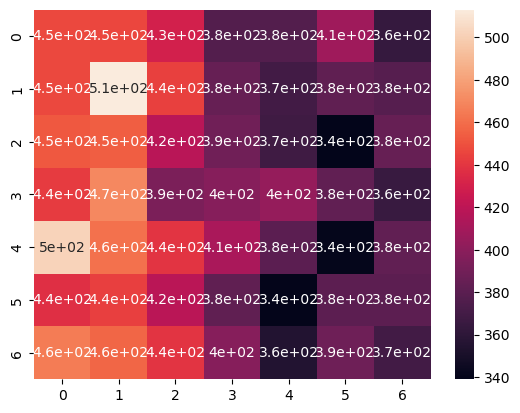

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True)
plt.show()

Step 12:   Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.14      0.16      0.15      2849
           1       0.16      0.18      0.17      2918
           2       0.14      0.15      0.14      2805
           3       0.15      0.14      0.14      2856
           4       0.15      0.13      0.14      2918
           5       0.15      0.14      0.14      2783
           6       0.14      0.13      0.13      2871

    accuracy                           0.15     20000
   macro avg       0.15      0.15      0.14     20000
weighted avg       0.15      0.15      0.14     20000



Step 13: Feature Importance

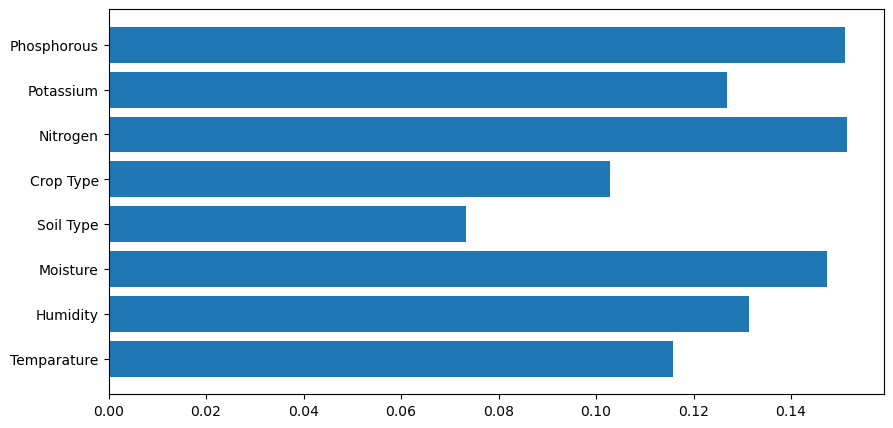

In [ ]:
importance = model.feature_importances_

features = x.columns

plt.figure(figsize=(10, 5))
plt.barh(features, importance)

plt.show()

Step 14: Save Model

In [ ]:
joblib.dump(model, 'fertilizer_model.pkl')

['fertilizer_model.pkl']

Manual Prediction

Step 1: check input columns

In [ ]:
x.columns     ## the order is very important

Index(['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous'],
      dtype='object')

Step 2: Encode Soil Type and Crop Type

In [ ]:
print(le_soil.classes_)

['Black' 'Clayey' 'Loamy' 'Red' 'Sandy']


In [ ]:
print(le_crop.classes_)

['Barley' 'Cotton' 'Ground Nuts' 'Maize' 'Millets' 'Oil seeds' 'Paddy'
 'Pulses' 'Sugarcane' 'Tobacco' 'Wheat']


Step 3: Give Manual input

In [ ]:
sample = [[35, 72, 47, 2, 4, 38, 1, 32]]

Step 4:  Predict

In [ ]:
prediction = model.predict(sample)

print(prediction)

[2]


c:\Users\Akhilesh Kumar\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
fertilizer_name = le_fertilizer.inverse_transform(prediction)

print(fertilizer_name)

[2]
